In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
df = pd.read_csv('bmw_global_sales.csv')
df

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
...,...,...,...,...,...,...,...,...,...,...,...
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41


In [82]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [83]:
df.tail()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41
3071,2025,12,RestOfWorld,MINI,6732,41811,281471652,0.167,5.89,2.37,1.41


In [84]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [86]:
df.shape

(3072, 11)

In [87]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


In [88]:
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [89]:
df.duplicated().sum()

np.int64(0)

In [90]:
num_cols = df.select_dtypes(include=np.number).columns
print("Numerical columns:", num_cols)
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['Year', 'Month', 'Units_Sold', 'Avg_Price_EUR', 'Revenue_EUR',
       'BEV_Share', 'Premium_Share', 'GDP_Growth', 'Fuel_Price_Index'],
      dtype='object')
Categorical columns: Index(['Region', 'Model'], dtype='object')


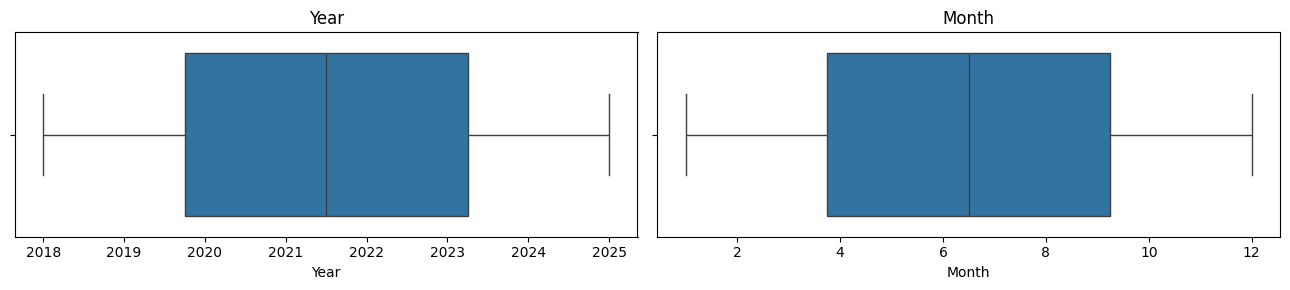

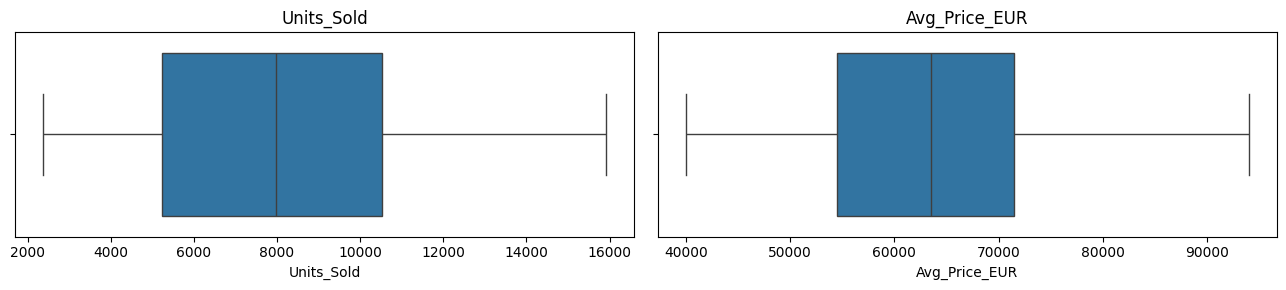

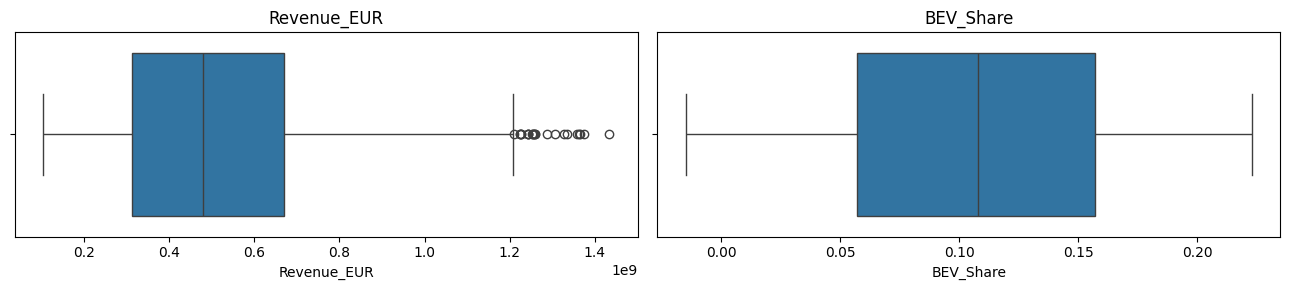

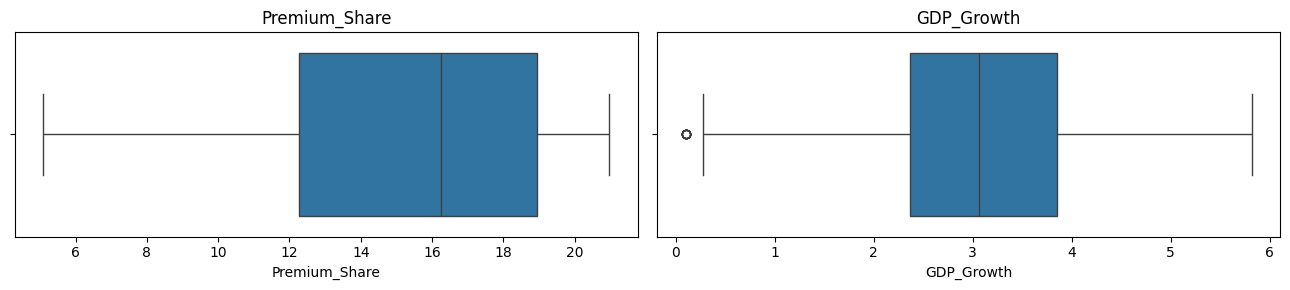

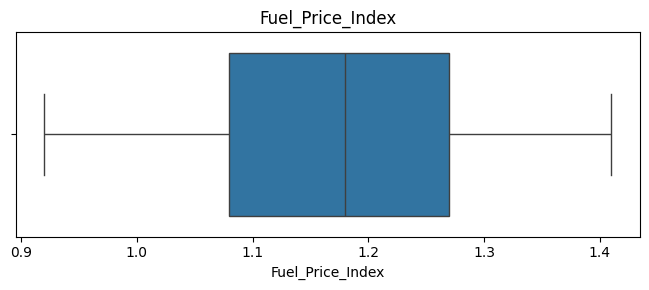

In [91]:
for i in range(0, len(num_cols), 2):
    fig = plt.figure(figsize=(13,3))

    plt.subplot(1,2,1)
    sns.boxplot(x=num_cols[i], data=df)
    plt.title(num_cols[i])

    if i+1 < len(num_cols):
        plt.subplot(1,2,2)
        sns.boxplot(x=num_cols[i+1], data=df)
        plt.title(num_cols[i+1])

    plt.tight_layout()
    plt.show()

In [92]:
for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col} → {len(outliers)} outliers")

Year → 0 outliers
Month → 0 outliers
Units_Sold → 0 outliers
Avg_Price_EUR → 0 outliers
Revenue_EUR → 23 outliers
BEV_Share → 0 outliers
Premium_Share → 0 outliers
GDP_Growth → 8 outliers
Fuel_Price_Index → 0 outliers


In [93]:
df.shape

(3072, 11)

In [94]:
df_clean = df.copy()

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

df_clean

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
...,...,...,...,...,...,...,...,...,...,...,...
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41


In [95]:
df_clean.shape

(3041, 11)

# EDA

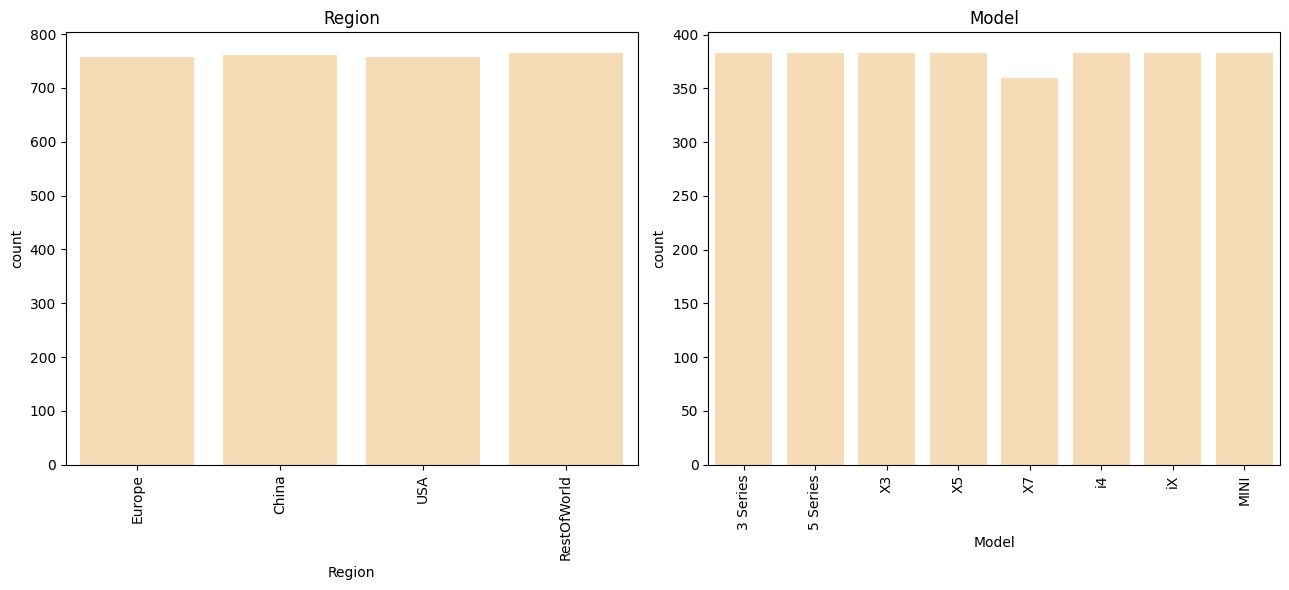

In [96]:
for i in range(0, len(categorical_cols), 2):
    fig = plt.figure(figsize=(13,6))

    plt.subplot(1,2,1)
    sns.countplot(x=categorical_cols[i], data=df_clean , color='navajowhite')
    plt.xticks(rotation=90)
    plt.title(categorical_cols[i])

    if i+1 < len(categorical_cols):
        plt.subplot(1,2,2)
        sns.countplot(x=categorical_cols[i+1], data=df_clean, color='navajowhite')
        plt.xticks(rotation=90)
        plt.title(categorical_cols[i+1])

    plt.tight_layout()
    plt.show()

## Convert Year and Month to datetime

In [97]:
df_clean['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

## Daily Revenue Summary

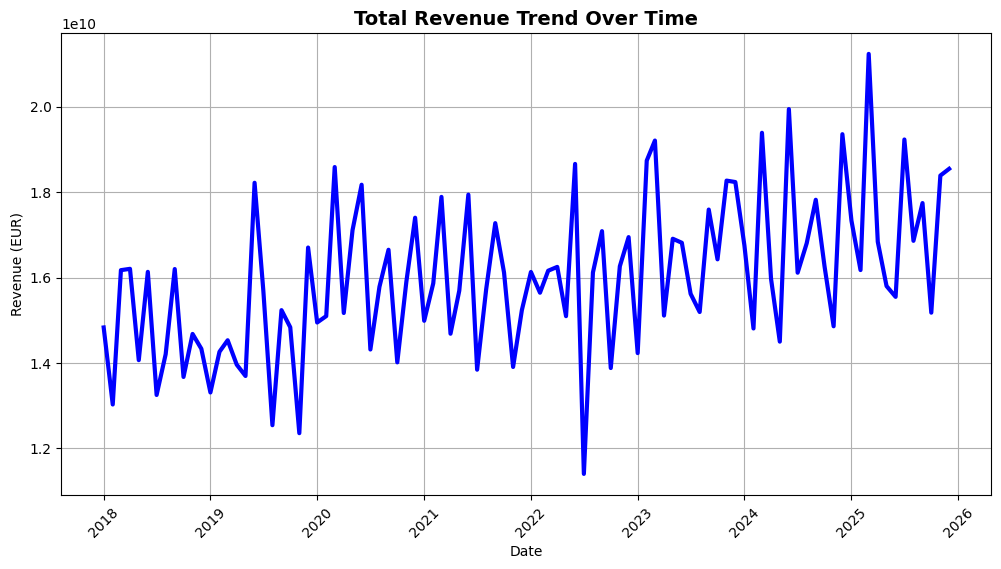

In [98]:
plt.figure(figsize=(12,6))

revenue_trend = df_clean.groupby('Date')['Revenue_EUR'].sum().reset_index()

plt.plot(revenue_trend['Date'], revenue_trend['Revenue_EUR'],
         color='blue', linewidth=3)

plt.title("Total Revenue Trend Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Revenue (EUR)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## Yearly Revenue Summary

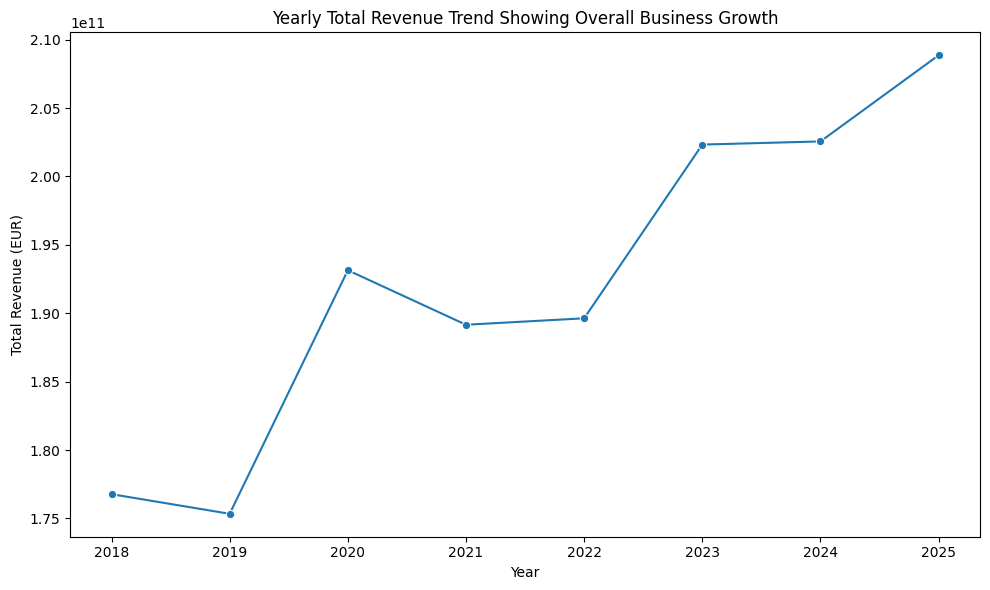

In [99]:
fig = plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_clean.groupby('Year')['Revenue_EUR'].sum().reset_index(),
    x='Year',
    y='Revenue_EUR',
    marker='o'
)

plt.title(f'Yearly Total Revenue Trend Showing Overall Business Growth')
plt.xlabel('Year')
plt.ylabel('Total Revenue (EUR)')
plt.tight_layout()
plt.show()

## Units sold by region

C:\Users\USER\AppData\Local\Temp\ipykernel_7484\1581611885.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.values,


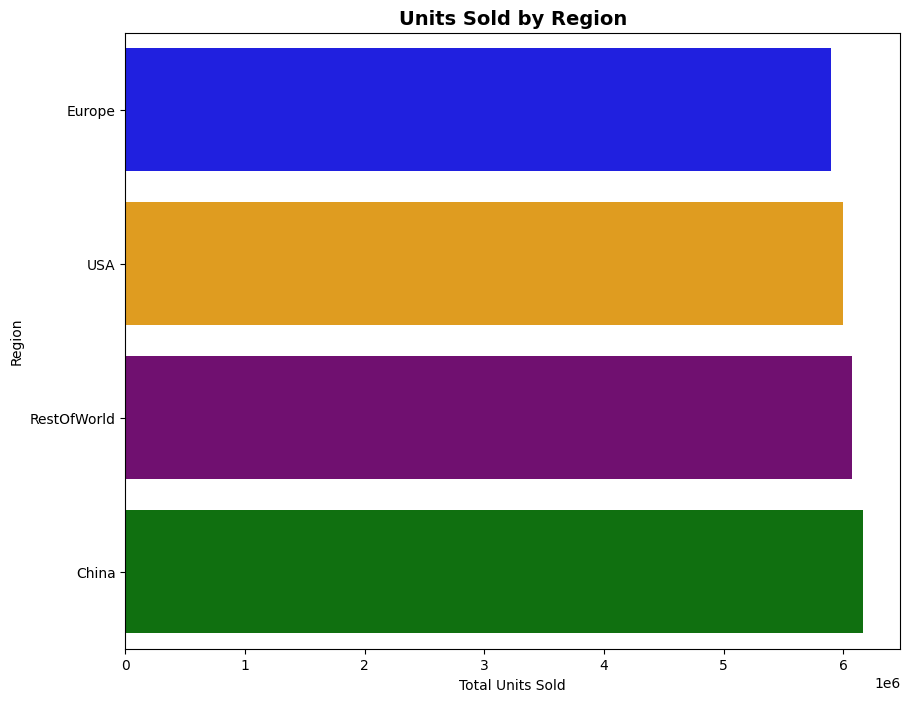

In [100]:
plt.figure(figsize=(10,8))

region_sales = df_clean.groupby('Region')['Units_Sold'].sum().sort_values()
colors = ['blue', 'orange', 'purple', 'green']

sns.barplot(x=region_sales.values,
            y=region_sales.index,
            palette=colors)

plt.title("Units Sold by Region", fontsize=14, fontweight='bold')
plt.xlabel("Total Units Sold")
plt.ylabel("Region")

plt.show()

## Model Types by Revenue

C:\Users\USER\AppData\Local\Temp\ipykernel_7484\836622765.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models.values,


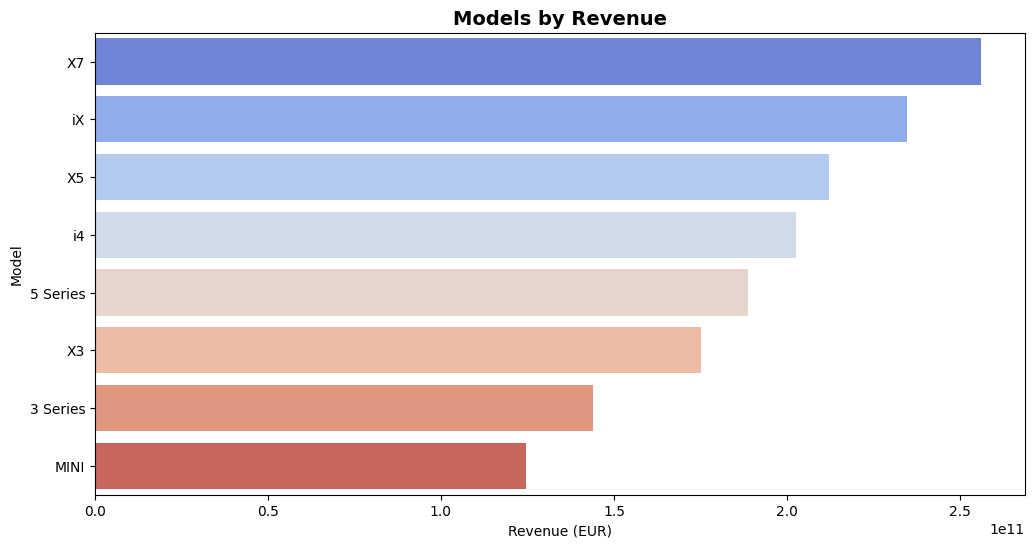

In [101]:
plt.figure(figsize=(12,6))

top_models = df_clean.groupby('Model')['Revenue_EUR'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_models.values,
            y=top_models.index,
            palette="coolwarm")

plt.title("Models by Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Revenue (EUR)")
plt.ylabel("Model")

plt.show()

## Average Sales Per Model

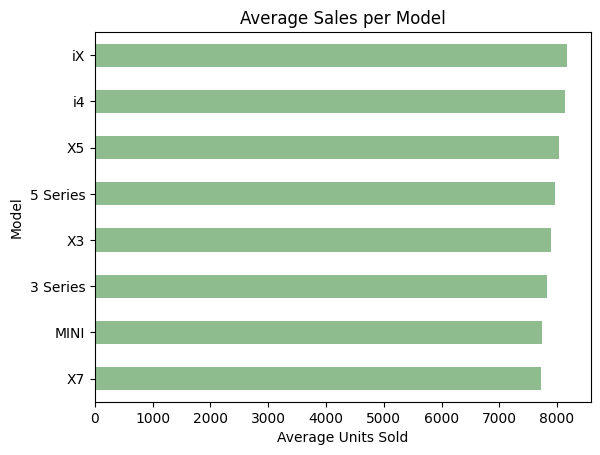

In [102]:
avg_sales = df_clean.groupby("Model")["Units_Sold"].mean().sort_values()

avg_sales.plot(kind="barh", color='darkseagreen')
plt.title("Average Sales per Model")
plt.xlabel("Average Units Sold")
plt.show()

## Average Monthly Revelue

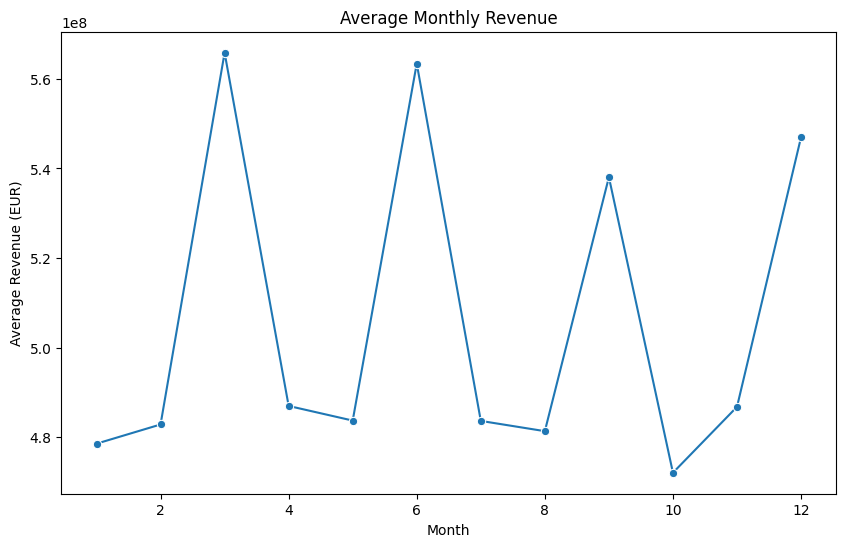

In [103]:
plt.figure(figsize=(10,6))

monthly_avg = df_clean.groupby('Month')['Revenue_EUR'].mean().reset_index()

sns.lineplot(data=monthly_avg, x='Month', y='Revenue_EUR', marker='o')

plt.title("Average Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Average Revenue (EUR)")
plt.show()

## Average Vehicle Price

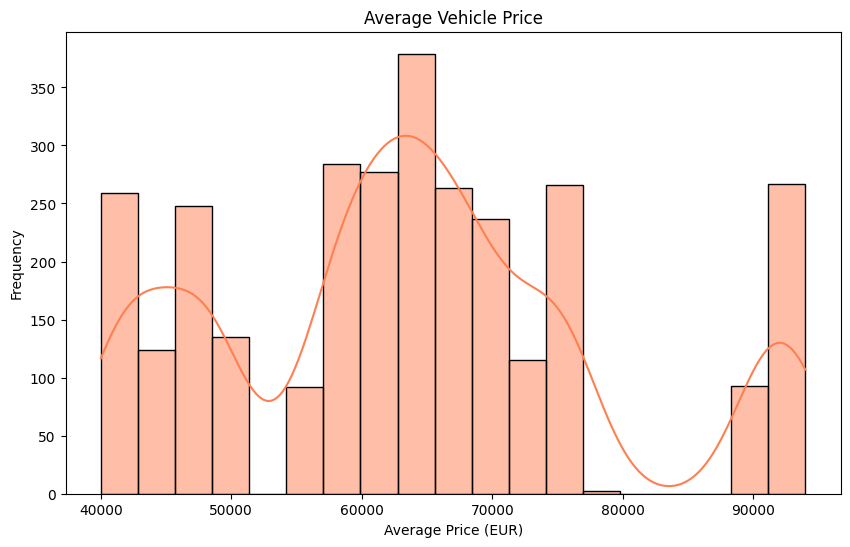

In [104]:
plt.figure(figsize=(10,6))

sns.histplot(df_clean['Avg_Price_EUR'], kde=True, color='coral')

plt.title("Average Vehicle Price")
plt.xlabel("Average Price (EUR)")
plt.ylabel("Frequency")

plt.show()

## Trends

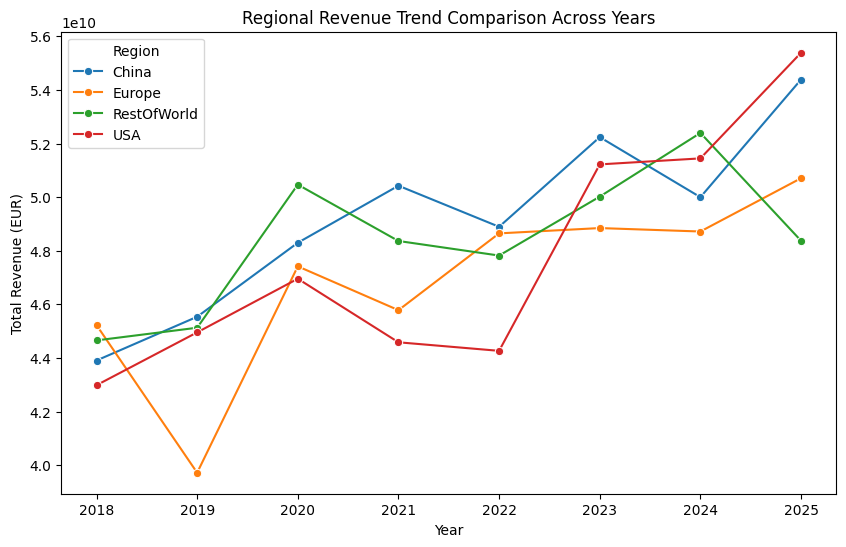

In [105]:
plt.figure(figsize=(10,6))

regional_trend = df_clean.groupby(['Year','Region'])['Revenue_EUR'].sum().reset_index()

sns.lineplot(
    data=regional_trend,
    x='Year',
    y='Revenue_EUR',
    hue='Region',
    marker='o'
)

plt.title("Regional Revenue Trend Comparison Across Years")
plt.xlabel("Year")
plt.ylabel("Total Revenue (EUR)")
plt.show()

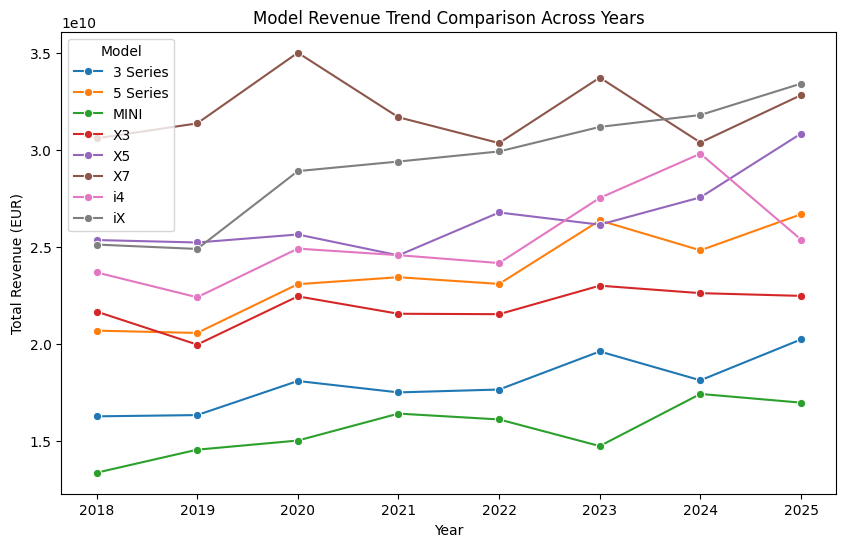

In [106]:
plt.figure(figsize=(10,6))

regional_trend = df_clean.groupby(['Year','Model'])['Revenue_EUR'].sum().reset_index()

sns.lineplot(
    data=regional_trend,
    x='Year',
    y='Revenue_EUR',
    hue='Model',
    marker='o'
)

plt.title("Model Revenue Trend Comparison Across Years")
plt.xlabel("Year")
plt.ylabel("Total Revenue (EUR)")
plt.show()

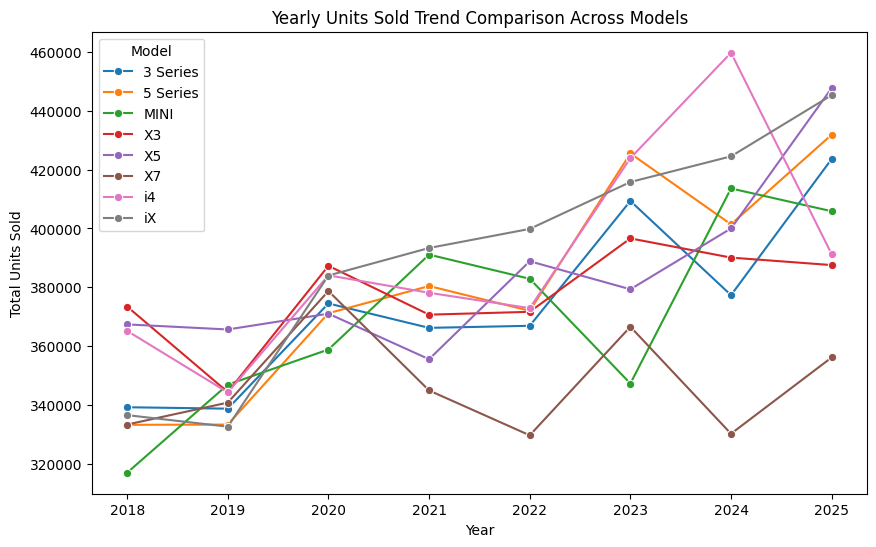

In [107]:
plt.figure(figsize=(10,6))

regional_trend = df_clean.groupby(['Year','Model'])['Units_Sold'].sum().reset_index()

sns.lineplot(
    data=regional_trend,
    x='Year',
    y='Units_Sold',
    hue='Model',
    marker='o'
)

plt.title("Yearly Units Sold Trend Comparison Across Models")
plt.xlabel("Year")
plt.ylabel("Total Units Sold")
plt.show()

## Correlation Heatmap

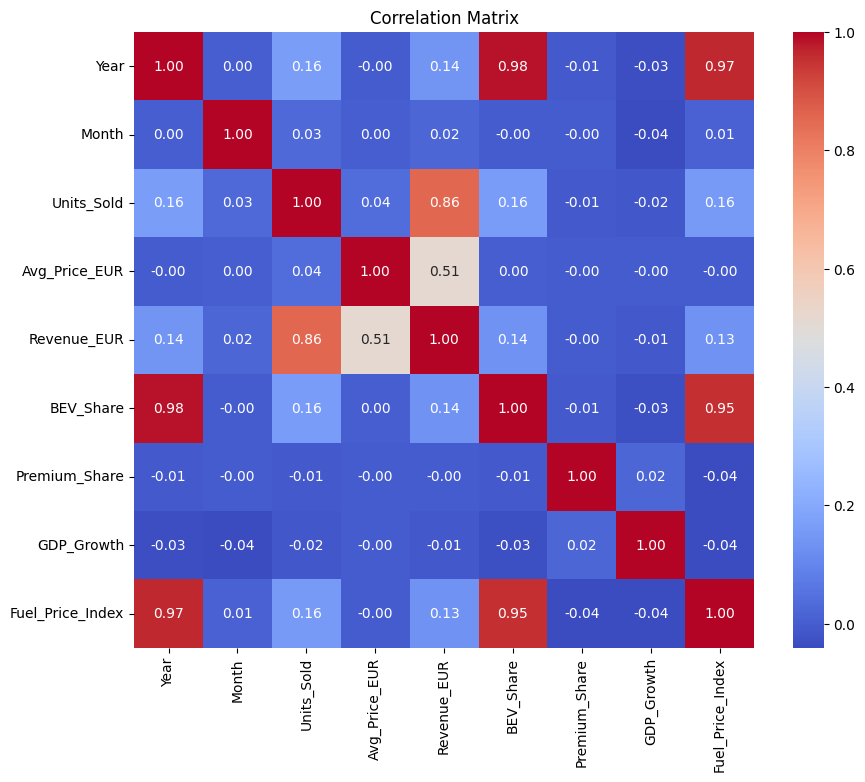

In [109]:
numeric_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()
